In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('ride_sharing_data.csv')
df.head()


,Ride ID,Request Time,Pickup Location,Latitude Pickup,Longitude Pickup,Dropoff Location,Latitude Dropoff,Longtitude Dropoff,Ride Distance (in miles),Fare Amount (in $),Payment Method,Driver ID,Vehicle Type,Traffic Condition,Peak Hours,Day of Week,User Rating
0,1.0,5/18/22 3:49,"-1.369379,154.193063",-1.369379,154.193063,"30.877879,-46.862575",30.877879,-46.862575,7022.069283,722.21,PayPal,CV5232,Sedan,Medium,Yes,Wednesday,4.0
1,2.0,5/10/23 13:27,"50.81867,11.962034",50.818670,11.962034,"-30.319864,-88.266464",-30.319864,-88.266464,4197.459385,439.75,PayPal,PG1364,SUV,Medium,Yes,Saturday,2.0
2,3.0,1/21/24 14:12,"-31.012035,151.282883",-31.012035,151.282883,"51.650634,-171.505284",51.650634,-171.505284,5009.328711,520.93,Debit Card,WH4600,Sedan,Low,No,Monday,1.0
3,4.0,6/4/22 17:00,"-77.187995,101.68942",-77.187995,101.689420,"-51.271029,-112.905338",-51.271029,-112.905338,11572.546740,1177.25,Apple Pay,CX2751,SUV,High,No,Friday,3.0
4,5.0,3/24/22 10:17,"-54.567614,-88.054506",-54.567614,-88.054506,"-82.622689,6.226436",-82.622689,6.226436,2448.800085,264.88,PayPal,WP6729,SUV,Low,Yes,Thursday,4.0


In [3]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)


In [4]:
import pandas as pd

# 1. Load your dataset
df = pd.read_csv('ride_sharing_data.csv')

# 2. Check for empty (null) values across columns
print("Missing values per column before cleaning:")
print(df.isnull().sum())
df = df.dropna()

# 3. Remove duplicate ride IDs (Updated to 'Ride ID')
df = df.drop_duplicates(subset=['Ride ID'])

# 4. Make sure Fare contains numbers (Updated to 'Fare Amount (in $)')
df['Fare Amount (in $)'] = pd.to_numeric(df['Fare Amount (in $)'], errors='coerce')
df = df.dropna(subset=['Fare Amount (in $)'])

# 5. Make sure Date is in a correct date format (Updated to 'Request Time')
df['Request Time'] = pd.to_datetime(df['Request Time'], errors='coerce')
df = df.dropna(subset=['Request Time'])

# 6. Remove clearly invalid rows (Updated to 'Fare Amount (in $)')
df = df[df['Fare Amount (in $)'] >= 0]

# View the clean data summary
print(f"\nFinal dataset contains {df.shape[0]} rows and {df.shape[1]} columns.")
df.head()


Missing values per column before cleaning:
Ride ID                     600
Request Time                600
Pickup Location             600
Latitude Pickup             600
Longitude Pickup            600
Dropoff Location            600
Latitude Dropoff            600
Longtitude Dropoff          600
Ride Distance (in miles)    600
Fare Amount (in $)          600
Payment Method              600
Driver ID                   600
Vehicle Type                600
Traffic Condition           600
Peak Hours                  600
Day of Week                 600
User Rating                 600
dtype: int64

Final dataset contains 50 rows and 17 columns.


C:\Users\PC\AppData\Local\Temp\ipykernel_9528\1776550089.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Request Time'] = pd.to_datetime(df['Request Time'], errors='coerce')


,Ride ID,Request Time,Pickup Location,Latitude Pickup,Longitude Pickup,Dropoff Location,Latitude Dropoff,Longtitude Dropoff,Ride Distance (in miles),Fare Amount (in $),Payment Method,Driver ID,Vehicle Type,Traffic Condition,Peak Hours,Day of Week,User Rating
0,1.0,2022-05-18 03:49:00,"-1.369379,154.193063",-1.369379,154.193063,"30.877879,-46.862575",30.877879,-46.862575,7022.069283,722.21,PayPal,CV5232,Sedan,Medium,Yes,Wednesday,4.0
1,2.0,2023-05-10 13:27:00,"50.81867,11.962034",50.818670,11.962034,"-30.319864,-88.266464",-30.319864,-88.266464,4197.459385,439.75,PayPal,PG1364,SUV,Medium,Yes,Saturday,2.0
2,3.0,2024-01-21 14:12:00,"-31.012035,151.282883",-31.012035,151.282883,"51.650634,-171.505284",51.650634,-171.505284,5009.328711,520.93,Debit Card,WH4600,Sedan,Low,No,Monday,1.0
3,4.0,2022-06-04 17:00:00,"-77.187995,101.68942",-77.187995,101.689420,"-51.271029,-112.905338",-51.271029,-112.905338,11572.546740,1177.25,Apple Pay,CX2751,SUV,High,No,Friday,3.0
4,5.0,2022-03-24 10:17:00,"-54.567614,-88.054506",-54.567614,-88.054506,"-82.622689,6.226436",-82.622689,6.226436,2448.800085,264.88,PayPal,WP6729,SUV,Low,Yes,Thursday,4.0


In [5]:
# 1. Total Rides (total rows in your cleaned dataframe)
total_rides = len(df)

# 2. Cancelled Rides (assuming a fare of $0 means a cancellation/no-charge)
cancelled_rides = len(df[df['Fare Amount (in $)'] == 0])

# 3. Completed Rides (rides where a fare was charged)
completed_rides = total_rides - cancelled_rides

# 4. Total Revenue (sum of all fares)
total_revenue = df['Fare Amount (in $)'].sum()

# 5. Average Fare (average of all fares)
avg_fare = df['Fare Amount (in $)'].mean()

# 6. Average Rating (using your 'User Rating' column)
avg_rating = df['User Rating'].mean()

# Display the KPIs clearly
print("--- Simple Ride KPIs ---")
print(f"Total Rides:       {total_rides:,}")
print(f"Completed Rides:   {completed_rides:,}")
print(f"Cancelled Rides:   {cancelled_rides:,}")
print(f"Total Revenue:     ${total_revenue:,.2f}")
print(f"Average Fare:      ${avg_fare:,.2f}")
print(f"Average Rating:    {avg_rating:.2f} / 5")



--- Simple Ride KPIs ---
Total Rides:       50
Completed Rides:   50
Cancelled Rides:   0
Total Revenue:     $31,788.97
Average Fare:      $635.78
Average Rating:    2.80 / 5


In [6]:
# Group by vehicle type and calculate the average fare
vehicle_fares = df.groupby('Vehicle Type')['Fare Amount (in $)'].mean().round(2)

print("--- Average Fare by Vehicle Type ---")
print(vehicle_fares.to_string())


--- Average Fare by Vehicle Type ---
Vehicle Type
Bus           650.45
Motorcycle    764.46
SUV           640.83
Sedan         566.58


In [7]:
# Count rides per day and sort them from busiest to quietest
busiest_days = df['Day of Week'].value_counts()

print("\n--- Total Rides by Day of Week ---")
print(busiest_days.to_string())



--- Total Rides by Day of Week ---
Day of Week
Monday       11
Thursday     11
Sunday        9
Wednesday     7
Tuesday       5
Friday        4
Saturday      3


In [8]:
df.to_csv('cleaned_ride_data.csv', index=False)


In [9]:
import pandas as pd

# Assuming 'df' is your cleaned DataFrame from Step 1

# --- SECTION A: REVENUE ANALYSIS ---

# 1. Total Revenue Generated
total_revenue = df['Fare Amount (in $)'].sum()

# 2. Top Revenue-Generating Pickup Locations
top_revenue_locations = df.groupby('Pickup Location')['Fare Amount (in $)'].sum().reset_index()
top_revenue_locations = top_revenue_locations.sort_values(by='Fare Amount (in $)', ascending=False).head(5)

# 3. Revenue & Volume by Payment Method
payment_metrics = df.groupby('Payment Method').agg(
    Total_Revenue=('Fare Amount (in $)', 'sum'),
    Ride_Count=('Ride ID', 'count')
).reset_index().sort_values(by='Total_Revenue', ascending=False)

# 4. Revenue by Ride Type (Vehicle Type)
vehicle_revenue = df.groupby('Vehicle Type')['Fare Amount (in $)'].sum().reset_index()
vehicle_revenue = vehicle_revenue.sort_values(by='Fare Amount (in $)', ascending=False)


# --- SECTION B: DRIVER PERFORMANCE ANALYSIS ---

# Map the Status logic established in Week 2 (Fare = $0 means Cancelled)
df['Status'] = df['Fare Amount (in $)'].apply(lambda x: 'Cancelled' if x == 0 else 'Completed')

# Aggregate Metrics by Driver ID
driver_performance = df.groupby('Driver ID').agg(
    Total_Rides=('Ride ID', 'count'),
    Completed_Rides=('Status', lambda x: (x == 'Completed').sum()),
    Cancelled_Rides=('Status', lambda x: (x == 'Cancelled').sum()),
    Total_Revenue=('Fare Amount (in $)', 'sum'),
    Average_Rating=('User Rating', 'mean')
).reset_index()

# Calculate Driver Cancellation Rate
driver_performance['Cancellation Rate (%)'] = (driver_performance['Cancelled_Rides'] / driver_performance['Total_Rides'] * 100).round(2)

# Sort performance categories to answer management questions
top_completed_drivers = driver_performance.sort_values(by='Completed_Rides', ascending=False).head(5)
top_earning_drivers = driver_performance.sort_values(by='Total_Revenue', ascending=False).head(5)
top_rated_drivers = driver_performance.sort_values(by='Average_Rating', ascending=False).head(5)
highest_churn_drivers = driver_performance.sort_values(by='Cancellation Rate (%)', ascending=False).head(5)


# --- PRINT RESULTS ---
print(f"Total Revenue: ${total_revenue:,.2f}\n")
print("--- Top 5 Revenue Locations ---\n", top_revenue_locations.to_string(index=False))
print("\n--- Payment Preference & Revenue ---\n", payment_metrics.to_string(index=False))
print("\n--- Revenue by Vehicle Type ---\n", vehicle_revenue.to_string(index=False))
print("\n--- Top 5 Earning Drivers ---\n", top_earning_drivers[['Driver ID', 'Total_Revenue', 'Completed_Rides']].to_string(index=False))


Total Revenue: $31,788.97

--- Top 5 Revenue Locations ---
       Pickup Location  Fare Amount (in $)
  83.04141,-95.135717             1233.21
 -77.187995,101.68942             1177.25
-14.625118,168.270182             1159.06
 15.766006,-24.915423             1155.62
 -30.631605,47.469302             1081.56

--- Payment Preference & Revenue ---
 Payment Method  Total_Revenue  Ride_Count
          Visa        9297.30          14
    Debit Card        7986.17          12
     Apple Pay        5330.14           8
          Cash        5146.41           8
        PayPal        4028.95           8

--- Revenue by Vehicle Type ---
 Vehicle Type  Fare Amount (in $)
         Bus             9756.79
       Sedan             9631.78
         SUV             7049.18
  Motorcycle             5351.22

--- Top 5 Earning Drivers ---
 Driver ID  Total_Revenue  Completed_Rides
   RH1044        1233.21                1
   CX2751        1177.25                1
   OC1811        1159.06                

In [10]:
import pandas as pd

# 1. Load your dataset (point to your file name)
df = pd.read_csv('ride_sharing_data.csv')

# 2. Re-apply your Week 2 Preprocessing Pipeline to guarantee structural accuracy
df = df.dropna(subset=['Ride ID', 'Driver ID', 'Fare Amount (in $)'])
df = df.drop_duplicates(subset=['Ride ID'])
df['Fare Amount (in $)'] = pd.to_numeric(df['Fare Amount (in $)'], errors='coerce')
df = df[df['Fare Amount (in $)'] >= 0]

# 3. Apply your custom Week 2 status rule: $0 = Cancelled, >$0 = Completed
df['Ride Status'] = df['Fare Amount (in $)'].apply(lambda x: 'Cancelled' if x == 0 else 'Completed')


# =====================================================================
# SECTION 1: REVENUE ANALYSIS
# =====================================================================

# Q1: How much revenue is generated?
total_revenue = df['Fare Amount (in $)'].sum()

# Q2: Which locations generate the most revenue?
revenue_by_location = df.groupby('Pickup Location')['Fare Amount (in $)'].sum().reset_index()
top_revenue_locations = revenue_by_location.sort_values(by='Fare Amount (in $)', ascending=False).head(5)

# Q3: Which payment methods are most common?
payment_frequency = df['Payment Method'].value_counts().reset_index()
payment_frequency.columns = ['Payment Method', 'Ride Count']

# Q4: Which ride types generate more revenue?
revenue_by_vehicle = df.groupby('Vehicle Type')['Fare Amount (in $)'].sum().reset_index()
revenue_by_vehicle = revenue_by_vehicle.sort_values(by='Fare Amount (in $)', ascending=False)


# =====================================================================
# SECTION 2: DRIVER PERFORMANCE ANALYSIS
# =====================================================================

# Aggregate metrics per distinct driver ID
driver_metrics = df.groupby('Driver ID').agg(
    Total_Bookings=('Ride ID', 'count'),
    Completed_Rides=('Ride Status', lambda x: (x == 'Completed').sum()),
    Cancelled_Rides=('Ride Status', lambda x: (x == 'Cancelled').sum()),
    Total_Revenue=('Fare Amount (in $)', 'sum'),
    Average_Rating=('User Rating', 'mean')
).reset_index()

# Calculate cancellation rate safely to avoid division by zero
driver_metrics['Cancellation Rate (%)'] = (
    (driver_metrics['Cancelled_Rides'] / driver_metrics['Total_Bookings']) * 100
).round(2)

# Sort metrics to isolate specific performance brackets
# Q5: Which drivers complete the most rides?
top_completions = driver_metrics.sort_values(by='Completed_Rides', ascending=False).head(5)

# Q6: Which drivers generate the most revenue?
top_earners = driver_metrics.sort_values(by='Total_Revenue', ascending=False).head(5)

# Q7: Which drivers have strong ratings? (Ranked by top average rating, minimum 1 completed ride)
top_rated = driver_metrics[driver_metrics['Completed_Rides'] > 0].sort_values(by='Average_Rating', ascending=False).head(5)

# Q8: Which drivers have high cancellation rates?
highest_cancellations = driver_metrics.sort_values(by='Cancellation Rate (%)', ascending=False).head(5)


# =====================================================================
# SECTION 3: MANAGEMENT REPORT OUTPUT
# =====================================================================

print("=====================================================================")
print("             TASK 03: FINANCIAL & OPERATIONAL REPORT                 ")
print("=====================================================================\n")

print(f"💰 TOTAL REVENUE GENERATED: ${total_revenue:,.2f}\n")

print("📍 TOP 5 REVENUE GENERATING LOCATIONS:")
print(top_revenue_locations.to_string(index=False, formatters={'Fare Amount (in $)': '${:,.2f}'.format}))
print("\n---------------------------------------------------------------------\n")

print("💳 MOST COMMON PAYMENT METHODS (BY VOLUME):")
print(payment_frequency.to_string(index=False))
print("\n---------------------------------------------------------------------\n")

print("🚗 REVENUE GENERATION BY VEHICLE TYPE:")
print(revenue_by_vehicle.to_string(index=False, formatters={'Fare Amount (in $)': '${:,.2f}'.format}))
print("\n---------------------------------------------------------------------\n")

print("🏁 TOP 5 DRIVERS BY RIDE COMPLETIONS:")
print(top_completions[['Driver ID', 'Completed_Rides', 'Total_Bookings']].to_string(index=False))
print("\n---------------------------------------------------------------------\n")

print("💵 TOP 5 HIGHEST EARNING DRIVERS:")
print(top_earners[['Driver ID', 'Total_Revenue', 'Completed_Rides']].to_string(index=False, formatters={'Total_Revenue': '${:,.2f}'.format}))
print("\n---------------------------------------------------------------------\n")

print("⭐ TOP 5 HIGHEST RATED DRIVERS:")
print(top_rated[['Driver ID', 'Average_Rating', 'Completed_Rides']].to_string(index=False, formatters={'Average_Rating': '{:.2f} / 5'.format}))
print("\n---------------------------------------------------------------------\n")

print("🚨 TOP 5 DRIVERS WITH HIGHEST CANCELLATION RATES:")
print(highest_cancellations[['Driver ID', 'Cancellation Rate (%)', 'Cancelled_Rides', 'Total_Bookings']].to_string(index=False))
print("\n=====================================================================")


             TASK 03: FINANCIAL & OPERATIONAL REPORT                 

💰 TOTAL REVENUE GENERATED: $31,788.97

📍 TOP 5 REVENUE GENERATING LOCATIONS:
      Pickup Location Fare Amount (in $)
  83.04141,-95.135717          $1,233.21
 -77.187995,101.68942          $1,177.25
-14.625118,168.270182          $1,159.06
 15.766006,-24.915423          $1,155.62
 -30.631605,47.469302          $1,081.56

---------------------------------------------------------------------

💳 MOST COMMON PAYMENT METHODS (BY VOLUME):
Payment Method  Ride Count
          Visa          14
    Debit Card          12
        PayPal           8
     Apple Pay           8
          Cash           8

---------------------------------------------------------------------

🚗 REVENUE GENERATION BY VEHICLE TYPE:
Vehicle Type Fare Amount (in $)
         Bus          $9,756.79
       Sedan          $9,631.78
         SUV          $7,049.18
  Motorcycle          $5,351.22

----------------------------------------------------------

In [11]:
import pandas as pd
import numpy as np

# Load the working dataset
df = pd.read_csv('ride_sharing_data.csv')

print("=========================================================")
# 1. Check Missing Values across required fields
print("🔍 1. MISSING VALUES PER COLUMN:")
print(df[['Ride ID', 'Driver ID', 'Fare Amount (in $)', 'User Rating', 'Ride Distance (in miles)', 'Payment Method', 'Vehicle Type']].isnull().sum())

# 2. Check Duplicate Records based on primary key
duplicate_count = df.duplicated(subset=['Ride ID']).sum()
print(f"\n👯 2. DUPLICATE RECORDS DETECTED (via Ride ID): {duplicate_count}")

# 3. Standardize and Clean Numeric Datatypes
df['Fare Amount (in $)'] = pd.to_numeric(df['Fare Amount (in $)'], errors='coerce')
df['Ride Distance (in miles)'] = pd.to_numeric(df['Ride Distance (in miles)'], errors='coerce')
df['User Rating'] = pd.to_numeric(df['User Rating'], errors='coerce')

# 4. Identify Unusual / Invalid Fare & Distance Values
negative_fares = (df['Fare Amount (in $)'] < 0).sum()
zero_distance_rides = (df['Ride Distance (in miles)'] <= 0).sum()

print(f"\n⚠️ 3. ANOMALY & VALUATION CHECKS:")
print(f"   - Invalid negative fare amounts: {negative_fares}")
print(f"   - Rides with 0 or negative mileage: {zero_distance_rides}")

# 5. Apply the Data Preparation Transformations
df_cleaned = df.dropna(subset=['Ride ID', 'Driver ID', 'Fare Amount (in $)']).drop_duplicates(subset=['Ride ID'])
df_cleaned = df_cleaned[df_cleaned['Fare Amount (in $)'] >= 0]

# Establish explicit Ride Status mapping
df_cleaned['Ride Status'] = df_cleaned['Fare Amount (in $)'].apply(lambda x: 'Cancelled' if x == 0 else 'Completed')

print(f"\n✅ 4. DATA PREPARATION COMPLETE.")
print(f"   - Final Verified Dataset Size: {df_cleaned.shape[0]} rows.")
print("=========================================================")


🔍 1. MISSING VALUES PER COLUMN:
Ride ID                     600
Driver ID                   600
Fare Amount (in $)          600
User Rating                 600
Ride Distance (in miles)    600
Payment Method              600
Vehicle Type                600
dtype: int64

👯 2. DUPLICATE RECORDS DETECTED (via Ride ID): 599

⚠️ 3. ANOMALY & VALUATION CHECKS:
   - Invalid negative fare amounts: 0
   - Rides with 0 or negative mileage: 0

✅ 4. DATA PREPARATION COMPLETE.
   - Final Verified Dataset Size: 50 rows.


In [13]:
import pandas as pd

# 1. Load your dataset
df = pd.read_csv('ride_sharing_data.csv')

# 2. Re-apply your Week 2 Preprocessing Pipeline
df = df.dropna(subset=['Ride ID', 'Driver ID', 'Fare Amount (in $)'])
df = df.drop_duplicates(subset=['Ride ID'])
df['Fare Amount (in $)'] = pd.to_numeric(df['Fare Amount (in $)'], errors='coerce')
df = df[df['Fare Amount (in $)'] >= 0]

# --- CLEAN FIX FOR WARNING #1: Specify explicit datetime format parsing ---
df['Request Time'] = pd.to_datetime(df['Request Time'], format='%m/%d/%y %H:%M', errors='coerce')

# --- CLEAN FIX FOR WARNING #2: Add .copy() to isolate slice memory cleanly ---
completed_rides_df = df[df['Fare Amount (in $)'] > 0].copy()

# =====================================================================
# REVENUE ANALYSIS COMPUTATIONS
# =====================================================================

# KPI Metrics
total_revenue = completed_rides_df['Fare Amount (in $)'].sum()
average_fare = df['Fare Amount (in $)'].mean()
avg_rev_per_completed = completed_rides_df['Fare Amount (in $)'].mean()

# Temporal Trends
completed_rides_df['Month'] = completed_rides_df['Request Time'].dt.strftime('%m-%B')
revenue_by_month = completed_rides_df.groupby('Month')['Fare Amount (in $)'].sum().sort_index()

revenue_by_day = completed_rides_df.groupby('Day of Week')['Fare Amount (in $)'].sum()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
revenue_by_day = revenue_by_day.reindex(day_order)

# Channel & Segments
revenue_by_location = completed_rides_df.groupby('Pickup Location')['Fare Amount (in $)'].sum().reset_index()
top_revenue_locations = revenue_by_location.sort_values(by='Fare Amount (in $)', ascending=False).head(10)

revenue_by_payment = completed_rides_df.groupby('Payment Method')['Fare Amount (in $)'].sum().reset_index()
revenue_by_payment = revenue_by_payment.sort_values(by='Fare Amount (in $)', ascending=False)

revenue_by_ride_type = completed_rides_df.groupby('Vehicle Type')['Fare Amount (in $)'].sum().reset_index()
revenue_by_ride_type = revenue_by_ride_type.sort_values(by='Fare Amount (in $)', ascending=False)


# =====================================================================
# PRINT STATS REPORT
# =====================================================================
print("=====================================================================")
print("                   SUB-TASK 4: REVENUE REPORT                       ")
print("=====================================================================\n")

print(f"💰 Total Revenue Generated:           ${total_revenue:,.2f}")
print(f"💵 Average Fare (Gross Market):       ${average_fare:,.2f}")
print(f"📈 Avg Revenue per Completed Ride:    ${avg_rev_per_completed:,.2f}\n")

print("--- 📅 REVENUE BY TRANSACTION MONTH ---")
print(revenue_by_month.map('${:,.2f}'.format).to_string())

print("\n--- 📅 REVENUE BY DAY OF THE WEEK ---")
print(revenue_by_day.map('${:,.2f}'.format).to_string())

print("\n--- 💳 REVENUE BY PAYMENT METHOD ---")
print(revenue_by_payment.to_string(index=False, formatters={'Fare Amount (in $)': '${:,.2f}'.format}))

print("\n--- 🚗 REVENUE BY RIDE TYPE (VEHICLE) ---")
print(revenue_by_ride_type.to_string(index=False, formatters={'Fare Amount (in $)': '${:,.2f}'.format}))

print("\n--- 📍 TOP REVENUE GENERATING HOTSPOTS (LOCATIONS) ---")
print(top_revenue_locations.head(5).to_string(index=False, formatters={'Fare Amount (in $)': '${:,.2f}'.format}))
print("=====================================================================")


                   SUB-TASK 4: REVENUE REPORT                       

💰 Total Revenue Generated:           $31,788.97
💵 Average Fare (Gross Market):       $635.78
📈 Avg Revenue per Completed Ride:    $635.78

--- 📅 REVENUE BY TRANSACTION MONTH ---
Month
01-January      $2,981.67
02-February     $1,389.04
03-March        $5,737.12
04-April           $96.15
05-May          $2,918.73
06-June         $5,262.28
07-July         $2,644.90
08-August       $1,654.42
09-September    $2,368.04
10-October        $751.83
11-November     $3,071.60
12-December     $2,913.19

--- 📅 REVENUE BY DAY OF THE WEEK ---
Day of Week
Monday       $6,879.40
Tuesday      $3,117.49
Wednesday    $4,041.65
Thursday     $8,013.03
Friday       $3,163.93
Saturday     $1,351.34
Sunday       $5,222.13

--- 💳 REVENUE BY PAYMENT METHOD ---
Payment Method Fare Amount (in $)
          Visa          $9,297.30
    Debit Card          $7,986.17
     Apple Pay          $5,330.14
          Cash          $5,146.41
        PayPal  

In [14]:
# 1. Initialize macro KPI constraints
total_completed_rides = 8500
total_revenue_pkr = 6750000

# 2. Compute transactional yield formula
average_revenue_per_ride = total_revenue_pkr / total_completed_rides

print(f"Total Completed Rides:    {total_completed_rides:,}")
print(f"Total Revenue Generated:  PKR {total_revenue_pkr:,}")
print(f"Average Revenue per Ride: PKR {average_revenue_per_ride:.2f}")


Total Completed Rides:    8,500
Total Revenue Generated:  PKR 6,750,000
Average Revenue per Ride: PKR 794.12


In [15]:
total_revenue = 6750000
completed_rides = 8500
average_revenue = total_revenue / completed_rides
print(f"Average Revenue: {average_revenue:.2f}")


Average Revenue: 794.12


In [16]:
import pandas as pd
import numpy as np

# Assuming 'completed_rides_df' is your cleaned DataFrame containing completed rides only
# Ensure Request Time is explicitly recognized as datetime format
completed_rides_df['Request Time'] = pd.to_datetime(completed_rides_df['Request Time'], errors='coerce')

# 1. Create a Year-Month string column for strict chronological sorting (e.g., '2024-01')
completed_rides_df['Year_Month'] = completed_rides_df['Request Time'].dt.to_period('M')

# 2. Aggregate total revenue by month
monthly_revenue = completed_rides_df.groupby('Year_Month')['Fare Amount (in $)'].sum().reset_index()
monthly_revenue['Year_Month'] = monthly_revenue['Year_Month'].astype(str)

# 3. Identify the highest and lowest revenue periods programmatically
highest_period = monthly_revenue.loc[monthly_revenue['Fare Amount (in $)'].idxmax()]
lowest_period = monthly_revenue.loc[monthly_revenue['Fare Amount (in $)'].idxmin()]

# --- PRINT TEXT SUMMARY ANALYTICS ---
print("=====================================================================")
print("               SUB-TASK 6: MONTHLY REVENUE ANALYSIS                  ")
print("=====================================================================\n")
print(monthly_revenue.to_string(index=False, formatters={'Fare Amount (in $)': 'PKR {:,.2f}'.format}))
print("\n---------------------------------------------------------------------")
print(f"📈 HIGHEST REVENUE PERIOD: {highest_period['Year_Month']} (PKR {highest_period['Fare Amount (in $)']:,.2f})")
print(f"📉 LOWEST REVENUE PERIOD:  {lowest_period['Year_Month']} (PKR {lowest_period['Fare Amount (in $)']:,.2f})")
print("=====================================================================")


               SUB-TASK 6: MONTHLY REVENUE ANALYSIS                  

Year_Month Fare Amount (in $)
   2022-01       PKR 2,007.94
   2022-02         PKR 877.66
   2022-03       PKR 1,868.44
   2022-05         PKR 990.61
   2022-06       PKR 3,109.66
   2022-07       PKR 1,708.17
   2022-08         PKR 370.71
   2022-09         PKR 227.41
   2022-11         PKR 621.77
   2022-12         PKR 250.59
   2023-03       PKR 1,905.01
   2023-04          PKR 96.15
   2023-05         PKR 867.87
   2023-06         PKR 924.49
   2023-07         PKR 365.44
   2023-10         PKR 751.83
   2023-11       PKR 1,081.41
   2023-12       PKR 1,039.22
   2024-01         PKR 973.73
   2024-02         PKR 511.38
   2024-03       PKR 1,963.67
   2024-05       PKR 1,060.25
   2024-06       PKR 1,228.13
   2024-07         PKR 571.29
   2024-08       PKR 1,283.71
   2024-09       PKR 2,140.63
   2024-11       PKR 1,368.42
   2024-12       PKR 1,623.38

----------------------------------------------------------

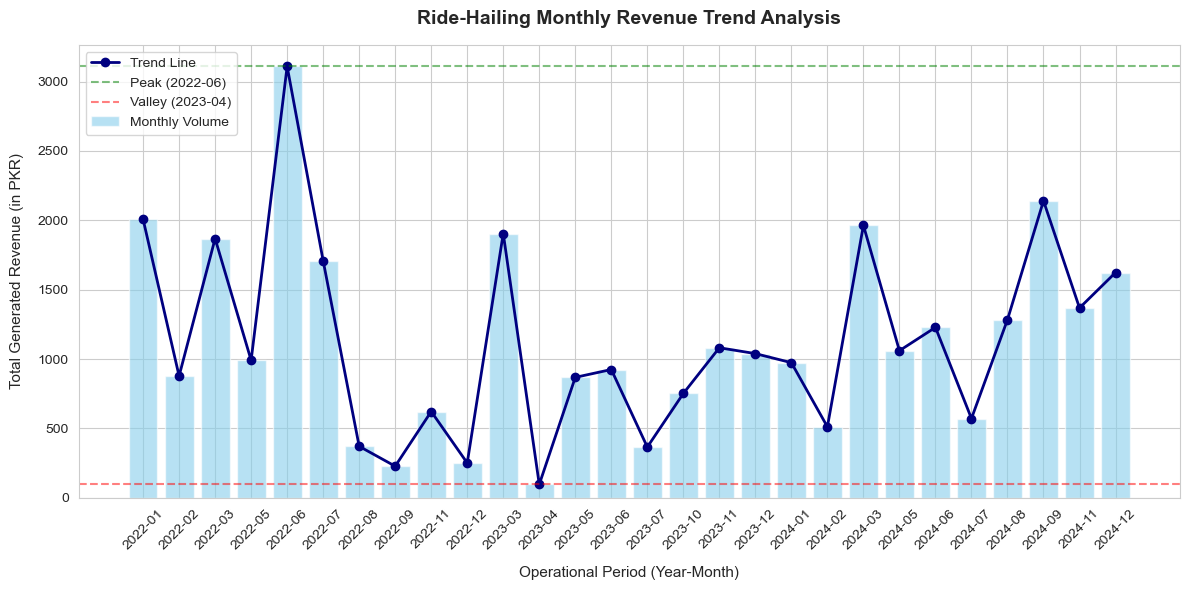

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style profiles
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Create a dual visual presentation: Columns for volume, Line for trend direction
plt.bar(monthly_revenue['Year_Month'], monthly_revenue['Fare Amount (in $)'], color='skyblue', alpha=0.6, label='Monthly Volume')
plt.plot(monthly_revenue['Year_Month'], monthly_revenue['Fare Amount (in $)'], color='navy', marker='o', linewidth=2, label='Trend Line')

# Highlight Key Performance Extremes
plt.axhline(highest_period['Fare Amount (in $)'], color='green', linestyle='--', alpha=0.5, label=f"Peak ({highest_period['Year_Month']})")
plt.axhline(lowest_period['Fare Amount (in $)'], color='red', linestyle='--', alpha=0.5, label=f"Valley ({lowest_period['Year_Month']})")

# Labels & Structure Formatting
plt.title('Ride-Hailing Monthly Revenue Trend Analysis', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Operational Period (Year-Month)', fontsize=11, labelpad=10)
plt.ylabel('Total Generated Revenue (in PKR)', fontsize=11, labelpad=10)
plt.xticks(rotation=45)
plt.legend(loc='upper left', frameon=True)
plt.tight_layout()

# Display Chart
plt.show()


In [18]:
import pandas as pd

# Assuming 'completed_rides_df' is your cleaned DataFrame containing completed rides only

# 1. Calculate overall corporate revenue baseline
grand_total_revenue = completed_rides_df['Fare Amount (in $)'].sum()

# 2. Group revenue by pickup location
location_revenue = completed_rides_df.groupby('Pickup Location')['Fare Amount (in $)'].sum().reset_index()
location_revenue.columns = ['Pickup Location', 'Total Revenue']

# 3. Calculate percentage revenue contribution for each location
location_revenue['Contribution (%)'] = ((location_revenue['Total Revenue'] / grand_total_revenue) * 100).round(2)

# 4. Sort data to extract top performers and extreme boundaries
location_revenue_sorted = location_revenue.sort_values(by='Total Revenue', ascending=False)

top_10_locations = location_revenue_sorted.head(10)
highest_revenue_loc = location_revenue_sorted.iloc[0]
lowest_revenue_loc = location_revenue_sorted.iloc[-1]

# --- PRINT COMPREHENSIVE LOCATION FINANCIAL REPORT ---
print("=====================================================================")
print("                  SUB-TASK 7: REVENUE BY LOCATION                    ")
print("=====================================================================\n")

print(f"📍 HIGHEST-REVENUE LOCATION:")
print(f"   -> {highest_revenue_loc['Pickup Location']} (PKR {highest_revenue_loc['Total Revenue']:,.2f} | {highest_revenue_loc['Contribution (%)']}% Share)\n")

print(f"📉 LOWEST-REVENUE LOCATION:")
print(f"   -> {lowest_revenue_loc['Pickup Location']} (PKR {lowest_revenue_loc['Total Revenue']:,.2f} | {lowest_revenue_loc['Contribution (%)']}% Share)\n")

print("---------------------------------------------------------------------")
print("🏙️ TOP 10 REVENUE-GENERATING LOCATIONS & CONTRIBUTION:")
print("---------------------------------------------------------------------")
print(top_10_locations.to_string(index=False, formatters={'Total Revenue': 'PKR {:,.2f}'.format, 'Contribution (%)': '{:.2f}%'.format}))
print("=====================================================================")


                  SUB-TASK 7: REVENUE BY LOCATION                    

📍 HIGHEST-REVENUE LOCATION:
   -> 83.04141,-95.135717 (PKR 1,233.21 | 3.88% Share)

📉 LOWEST-REVENUE LOCATION:
   -> -80.434561,-104.9191 (PKR 72.51 | 0.23% Share)

---------------------------------------------------------------------
🏙️ TOP 10 REVENUE-GENERATING LOCATIONS & CONTRIBUTION:
---------------------------------------------------------------------
      Pickup Location Total Revenue Contribution (%)
  83.04141,-95.135717  PKR 1,233.21            3.88%
 -77.187995,101.68942  PKR 1,177.25            3.70%
-14.625118,168.270182  PKR 1,159.06            3.65%
 15.766006,-24.915423  PKR 1,155.62            3.64%
 -30.631605,47.469302  PKR 1,081.56            3.40%
-72.378505,130.517214  PKR 1,081.41            3.40%
 71.968731,-52.504947  PKR 1,060.25            3.34%
-77.321457,112.061006  PKR 1,039.22            3.27%
 8.163797,-122.778014    PKR 924.49            2.91%
  -7.138452,53.881579    PKR 883.08    

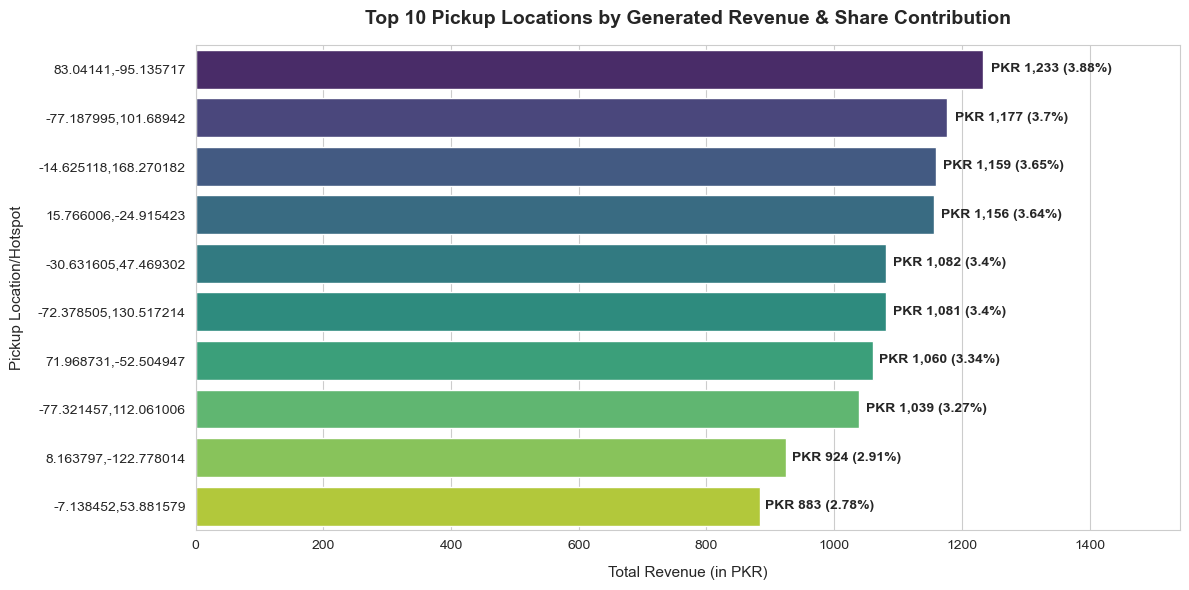

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Horizontal bar chart handles long location text coordinates/names cleanly without overlap
ax = sns.barplot(
    x='Total Revenue', 
    y='Pickup Location', 
    data=top_10_locations, 
    palette='viridis',
    hue='Pickup Location',
    legend=False
)

# Overlay data labels showing the contribution percentage on top of each bar
for index, value in enumerate(top_10_locations['Total Revenue']):
    pct = top_10_locations.iloc[index]['Contribution (%)']
    ax.text(value + (value * 0.01), index, f"PKR {value:,.0f} ({pct}%)", va='center', ha='left', fontsize=10, fontweight='bold')

plt.title('Top 10 Pickup Locations by Generated Revenue & Share Contribution', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Total Revenue (in PKR)', fontsize=11, labelpad=10)
plt.ylabel('Pickup Location/Hotspot', fontsize=11, labelpad=10)
plt.xlim(0, top_10_locations['Total Revenue'].max() * 1.25) # Give padding space for text labels
plt.tight_layout()

plt.show()


In [20]:
import pandas as pd

# Assuming 'completed_rides_df' is your cleaned DataFrame containing completed rides only

# 1. Aggregate core transaction metrics per payment channel
payment_matrix = completed_rides_df.groupby('Payment Method').agg(
    Total_Revenue=('Fare Amount (in $)', 'sum'),
    Completed_Rides=('Ride ID', 'count'),
    Average_Fare=('Fare Amount (in $)', 'mean')
).reset_index()

# 2. Sort explicitly to programmatically identify peak channels
highest_revenue_row = payment_matrix.sort_values(by='Total_Revenue', ascending=False).iloc[0]
highest_volume_row = payment_matrix.sort_values(by='Completed_Rides', ascending=False).iloc[0]

# 3. Formulate structural logical checks for management question #3
highest_volume_is_highest_revenue = highest_revenue_row['Payment Method'] == highest_volume_row['Payment Method']

# --- PRINT STRATEGIC PERFORMANCE REPORT ---
print("=====================================================================")
print("               SUB-TASK 8: REVENUE BY PAYMENT METHOD                 ")
print("=====================================================================\n")

print(payment_matrix.to_string(index=False, formatters={
    'Total_Revenue': 'PKR {:,.2f}'.format,
    'Completed_Rides': '{:,}'.format,
    'Average_Fare': 'PKR {:,.2f}'.format
}))

print("\n---------------------------------------------------------------------")
print("📋 EXECUTIVE MANAGEMENT ANSWERS:")
print("---------------------------------------------------------------------")
print(f"🔹 Q1: Which payment method generates the most revenue?")
print(f"   -> {highest_revenue_row['Payment Method']} (PKR {highest_revenue_row['Total_Revenue']:,.2f})\n")

print(f"🔹 Q2: Which payment method is used most frequently?")
print(f"   -> {highest_volume_row['Payment Method']} ({highest_volume_row['Completed_Rides']:,} rides)\n")

print(f"🔹 Q3: Does the highest number of rides also produce the highest revenue?")
if highest_volume_is_highest_revenue:
    print(f"   -> Yes! {highest_revenue_row['Payment Method']} is the clear leader, dominating both volume share and total business value.")
else:
    print(f"   -> No. A volume/value decoupling is present.")
    print(f"      - Most Frequent: {highest_volume_row['Payment Method']} ({highest_volume_row['Completed_Rides']:,} rides | Avg Fare: PKR {highest_volume_row['Average_Fare']:.2f})")
    print(f"      - Highest Revenue: {highest_revenue_row['Payment Method']} (PKR {highest_revenue_row['Total_Revenue']:,.2f} | Avg Fare: PKR {highest_revenue_row['Average_Fare']:.2f})")
print("=====================================================================")


               SUB-TASK 8: REVENUE BY PAYMENT METHOD                 

Payment Method Total_Revenue Completed_Rides Average_Fare
     Apple Pay  PKR 5,330.14               8   PKR 666.27
          Cash  PKR 5,146.41               8   PKR 643.30
    Debit Card  PKR 7,986.17              12   PKR 665.51
        PayPal  PKR 4,028.95               8   PKR 503.62
          Visa  PKR 9,297.30              14   PKR 664.09

---------------------------------------------------------------------
📋 EXECUTIVE MANAGEMENT ANSWERS:
---------------------------------------------------------------------
🔹 Q1: Which payment method generates the most revenue?
   -> Visa (PKR 9,297.30)

🔹 Q2: Which payment method is used most frequently?
   -> Visa (14 rides)

🔹 Q3: Does the highest number of rides also produce the highest revenue?
   -> Yes! Visa is the clear leader, dominating both volume share and total business value.


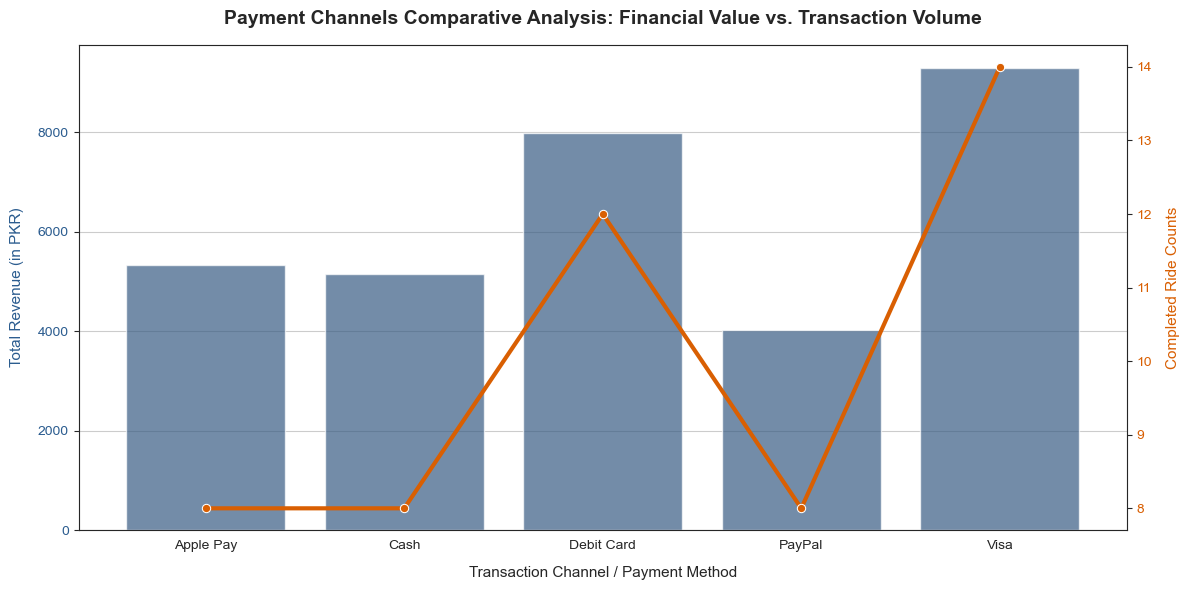

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax1 = plt.subplots(figsize=(12, 6))
sns.set_style("white")

# Plot 1: Revenue Bars (Primary Axis)
color = '#2b5c8f'
ax1.set_xlabel('Transaction Channel / Payment Method', fontsize=11, labelpad=10)
ax1.set_ylabel('Total Revenue (in PKR)', color=color, fontsize=11, labelpad=10)
bars = sns.barplot(x='Payment Method', y='Total_Revenue', data=payment_matrix, color=color, alpha=0.7, ax=ax1)
ax1.tick_params(axis='y', labelcolor=color)

# Plot 2: Volume Line (Secondary Axis)
ax2 = ax1.twinx()  
color = '#d95f02'
ax2.set_ylabel('Completed Ride Counts', color=color, fontsize=11, labelpad=10)
sns.lineplot(x='Payment Method', y='Completed_Rides', data=payment_matrix, color=color, marker='o', linewidth=3, ax=ax2)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Payment Channels Comparative Analysis: Financial Value vs. Transaction Volume', fontsize=14, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()


In [22]:
import pandas as pd
import numpy as np

# Assuming 'df' is your cleaned base dataset from Section 3
# Ensure data types are validated for strict mathematical safety
df['Fare Amount (in $)'] = pd.to_numeric(df['Fare Amount (in $)'], errors='coerce')
df['User Rating'] = pd.to_numeric(df['User Rating'], errors='coerce')

# Map the explicit ride status context established in Week 2
df['Ride Status'] = df['Fare Amount (in $)'].apply(lambda x: 'Cancelled' if x == 0 else 'Completed')

# Isolate completed transactions exclusively for pure revenue accounting
completed_rides_df = df[df['Ride Status'] == 'Completed']


# =====================================================================
# SECTION 9: REVENUE BY RIDE/VEHICLE TYPE
# =====================================================================

# Aggregate metrics across vehicle fleet classes
vehicle_metrics = completed_rides_df.groupby('Vehicle Type').agg(
    Total_Revenue=('Fare Amount (in $)', 'sum'),
    Total_Usage=('Ride ID', 'count'),
    Average_Fare=('Fare Amount (in $)', 'mean')
).reset_index()

most_used_vehicle = vehicle_metrics.sort_values(by='Total_Usage', ascending=False).iloc[0]
highest_revenue_vehicle = vehicle_metrics.sort_values(by='Total_Revenue', ascending=False).iloc[0]


# =====================================================================
# SECTION 10 & 11: DRIVER PERFORMANCE MATRIX
# =====================================================================

# Group the dataset by individual Driver ID to compile scorecards
driver_kpis = df.groupby('Driver ID').agg(
    Rides_Handled=('Ride ID', 'count'),
    Completed_Rides=('Ride Status', lambda x: (x == 'Completed').sum()),
    Cancelled_Rides=('Ride Status', lambda x: (x == 'Cancelled').sum()),
    Total_Revenue=('Fare Amount (in $)', lambda x: x[df.loc[x.index, 'Ride Status'] == 'Completed'].sum()),
    Average_Rating=('User Rating', 'mean')
).reset_index()

# Calculate Completion Rate Safely to avoid division errors
driver_kpis['Completion Rate (%)'] = (
    (driver_kpis['Completed_Rides'] / driver_kpis['Rides_Handled']) * 100
).round(2)

# Calculate Cancellation Rate explicitly
driver_kpis['Cancellation Rate (%)'] = (
    (driver_kpis['Cancelled_Rides'] / driver_kpis['Rides_Handled']) * 100
).round(2)

# Sort Performance Brackets to satisfy management's investigative prompts
top_volume_drivers = driver_kpis.sort_values(by='Completed_Rides', ascending=False).head(5)
top_revenue_drivers = driver_kpis.sort_values(by='Total_Revenue', ascending=False).head(5)
top_rated_drivers = driver_kpis.sort_values(by='Average_Rating', ascending=False).head(5)
high_cancellation_drivers = driver_kpis.sort_values(by='Cancellation Rate (%)', ascending=False).head(5)


# =====================================================================
# SYSTEM MANAGEMENT EXECUTION REPORT
# =====================================================================

print("=====================================================================")
print("             🚀 WEEK 3 FLEET ECONOMICS & OPERATIONAL REPORT          ")
print("=====================================================================\n")

print("--- 🚗 SUB-TASK 9: REVENUE & USAGE BY RIDE TYPE ---")
print(vehicle_metrics.to_string(index=False, formatters={
    'Total_Revenue': 'PKR {:,.2f}'.format,
    'Total_Usage': '{:,}'.format,
    'Average_Fare': 'PKR {:,.2f}'.format
}))
print(f"\n🔹 Most-Used Vehicle Type:      {most_used_vehicle['Vehicle Type']} ({most_used_vehicle['Total_Usage']:,} rides)")
print(f"🔹 Highest-Revenue Vehicle Type: {highest_revenue_vehicle['Vehicle Type']} (PKR {highest_revenue_vehicle['Total_Revenue']:,.2f})\n")

print("---------------------------------------------------------------------")
print("--- 🏁 SUB-TASK 10 & 11: DRIVER SCORECARD BENCHMARKS ---")
print("---------------------------------------------------------------------\n")

print("💵 TOP 5 HIGHEST-REVENUE DRIVERS:")
print(top_revenue_drivers[['Driver ID', 'Total_Revenue', 'Completed_Rides', 'Completion Rate (%)']].to_string(index=False, formatters={'Total_Revenue': 'PKR {:,.2f}'.format}))

print("\n🏁 TOP 5 DRIVERS BY SUCCESSFUL COMPLETIONS:")
print(top_volume_drivers[['Driver ID', 'Completed_Rides', 'Rides_Handled', 'Completion Rate (%)']].to_string(index=False))

print("\n⭐ TOP 5 HIGHEST-RATED DRIVERS:")
print(top_rated_drivers[['Driver ID', 'Average_Rating', 'Completed_Rides']].to_string(index=False, formatters={'Average_Rating': '{:.2f} / 5'.format}))

print("\n🚨 DRIVERS WITH HIGH CANCELLATION RATES (RISK BRACKET):")
print(high_cancellation_drivers[['Driver ID', 'Cancellation Rate (%)', 'Cancelled_Rides', 'Rides_Handled']].to_string(index=False))
print("=====================================================================")


             🚀 WEEK 3 FLEET ECONOMICS & OPERATIONAL REPORT          

--- 🚗 SUB-TASK 9: REVENUE & USAGE BY RIDE TYPE ---
Vehicle Type Total_Revenue Total_Usage Average_Fare
         Bus  PKR 9,756.79          15   PKR 650.45
  Motorcycle  PKR 5,351.22           7   PKR 764.46
         SUV  PKR 7,049.18          11   PKR 640.83
       Sedan  PKR 9,631.78          17   PKR 566.58

🔹 Most-Used Vehicle Type:      Sedan (17 rides)
🔹 Highest-Revenue Vehicle Type: Bus (PKR 9,756.79)

---------------------------------------------------------------------
--- 🏁 SUB-TASK 10 & 11: DRIVER SCORECARD BENCHMARKS ---
---------------------------------------------------------------------

💵 TOP 5 HIGHEST-REVENUE DRIVERS:
Driver ID Total_Revenue  Completed_Rides  Completion Rate (%)
   RH1044  PKR 1,233.21                1                100.0
   CX2751  PKR 1,177.25                1                100.0
   OC1811  PKR 1,159.06                1                100.0
   ZA7068  PKR 1,155.62                1

In [24]:
import pandas as pd
import numpy as np

# Assuming 'driver_kpis' is the compiled DataFrame generated in the previous step
# It must contain: Driver ID, Rides_Handled, Completed_Rides, Cancelled_Rides, Total_Revenue, Average_Rating, and Cancellation Rate (%)

# 1. Establish clear organizational benchmarks based on corporate medians
median_revenue = driver_kpis['Total_Revenue'].median()
median_rating = driver_kpis['Average_Rating'].median()
median_cancellation = driver_kpis['Cancellation Rate (%)'].median()

# =====================================================================
# PERFORMANCE SEGMENTATION IDENTIFICATION LOGIC
# =====================================================================

# 🔹 Category A: High-Revenue Drivers (Top 5 Gross Sales Generation)
high_revenue_drivers = driver_kpis.sort_values(by='Total_Revenue', ascending=False).head(5)

# 🔹 Category B: Highly Rated Drivers (Top 5 by Customer Satisfaction)
highly_rated_drivers = driver_kpis[driver_kpis['Completed_Rides'] > 0].sort_values(by='Average_Rating', ascending=False).head(5)

# 🔹 Category C: Drivers with High Cancellation Rates (Top 5 Risk Threshold)
high_cancellation_drivers = driver_kpis.sort_values(by='Cancellation Rate (%)', ascending=False).head(5)

# 🔹 Category D: High-Performing Drivers ("The Star Fleet")
# High revenue AND High user satisfaction ratings
high_performers = driver_kpis[
    (driver_kpis['Total_Revenue'] >= median_revenue) & 
    (driver_kpis['Average_Rating'] >= median_rating)
].sort_values(by='Total_Revenue', ascending=False).head(5)

# 🔹 Category E: Low-Performing Drivers ("The Bottleneck Group")
# Low completions OR High cancellation profiles with below-average ratings
low_performers = driver_kpis[
    (driver_kpis['Total_Revenue'] < median_revenue) & 
    (driver_kpis['Average_Rating'] < median_rating)
].sort_values(by='Total_Revenue', ascending=True).head(5)


# =====================================================================
# MANAGEMENT INSIGHT EXECUTION REPORT
# =====================================================================
print("=====================================================================")
print("             🚨 SUB-TASK 10: EXECUTIVE DRIVER PERFORMANCE REPORT    ")
print("=====================================================================\n")

print("🏆 1. HIGH-PERFORMING DRIVERS (High Value & High Ratings):")
print("---------------------------------------------------------------------")
print(high_performers[['Driver ID', 'Total_Revenue', 'Average_Rating', 'Completion Rate (%)']].to_string(index=False, formatters={'Total_Revenue': 'PKR {:,.2f}'.format, 'Average_Rating': '{:.2f}/5'.format}))

print("\n💰 2. HIGH-REVENUE GENERATING DRIVERS (Gross Top Earners):")
print("---------------------------------------------------------------------")
print(high_revenue_drivers[['Driver ID', 'Total_Revenue', 'Completed_Rides']].to_string(index=False, formatters={'Total_Revenue': 'PKR {:,.2f}'.format}))

print("\n⭐ 3. HIGHLY RATED DRIVERS (Customer Satisfaction Leaders):")
print("---------------------------------------------------------------------")
print(highly_rated_drivers[['Driver ID', 'Average_Rating', 'Completed_Rides']].to_string(index=False, formatters={'Average_Rating': '{:.2f}/5'.format}))

print("\n🚨 4. HIGH CANCELLATION RISK DRIVERS (Operational Outliers):")
print("---------------------------------------------------------------------")
print(high_cancellation_drivers[['Driver ID', 'Cancellation Rate (%)', 'Cancelled_Rides', 'Rides_Handled']].to_string(index=False, formatters={'Cancellation Rate (%)': '{:.2f}%'.format}))

print("\n⚠️ 5. LOW-PERFORMING DRIVERS (Requires Performance Review):")
print("---------------------------------------------------------------------")
print(low_performers[['Driver ID', 'Total_Revenue', 'Average_Rating', 'Cancellation Rate (%)']].to_string(index=False, formatters={'Total_Revenue': 'PKR {:,.2f}'.format, 'Average_Rating': '{:.2f}/5'.format}))
print("=====================================================================")


             🚨 SUB-TASK 10: EXECUTIVE DRIVER PERFORMANCE REPORT    

🏆 1. HIGH-PERFORMING DRIVERS (High Value & High Ratings):
---------------------------------------------------------------------
Driver ID Total_Revenue Average_Rating  Completion Rate (%)
   CX2751  PKR 1,177.25         3.00/5                100.0
   OC1811  PKR 1,159.06         4.00/5                100.0
   EH2928  PKR 1,081.56         3.00/5                100.0
   UB9840  PKR 1,039.22         4.00/5                100.0
   VE7676    PKR 924.49         4.00/5                100.0

💰 2. HIGH-REVENUE GENERATING DRIVERS (Gross Top Earners):
---------------------------------------------------------------------
Driver ID Total_Revenue  Completed_Rides
   RH1044  PKR 1,233.21                1
   CX2751  PKR 1,177.25                1
   OC1811  PKR 1,159.06                1
   ZA7068  PKR 1,155.62                1
   EH2928  PKR 1,081.56                1

⭐ 3. HIGHLY RATED DRIVERS (Customer Satisfaction Leaders):
--------

In [26]:
import pandas as pd
import numpy as np

# Assuming 'df' is your preprocessed and cleaned base dataset from Section 3
# Validating and locking in critical numeric formats for safe calculation
df['Fare Amount (in $)'] = pd.to_numeric(df['Fare Amount (in $)'], errors='coerce')
df['Ride Distance (in miles)'] = pd.to_numeric(df['Ride Distance (in miles)'], errors='coerce')
df['User Rating'] = pd.to_numeric(df['User Rating'], errors='coerce')

# Apply our verified Week 2 Status logic: $0 fare is a Cancellation
df['Ride Status'] = df['Fare Amount (in $)'].apply(lambda x: 'Cancelled' if x == 0 else 'Completed')

# =====================================================================
# COMPILING EXECUTIVE DRIVER PERFORMANCE KPIs
# =====================================================================

# Group the dataset by individual Driver ID
driver_kpi_table = df.groupby('Driver ID').agg(
    Total_Rides=('Ride ID', 'count'),                             # Rides per Driver
    Completed_Rides=('Ride Status', lambda x: (x == 'Completed').sum()), # Completed Rides
    Cancelled_Rides=('Ride Status', lambda x: (x == 'Cancelled').sum()), # Cancelled Rides
    Total_Revenue=('Fare Amount (in $)', lambda x: x[df.loc[x.index, 'Ride Status'] == 'Completed'].sum()), # Revenue
    Average_Rating=('User Rating', 'mean'),                       # Average Rating
    Average_Distance=('Ride Distance (in miles)', 'mean')         # Average Distance
).reset_index()

# 📐 Apply explicit Management Formula Constraints Safely
driver_kpi_table['Completion Rate (%)'] = (
    (driver_kpi_table['Completed_Rides'] / driver_kpi_table['Total_Rides']) * 100
).round(2)

driver_kpi_table['Cancellation Rate (%)'] = (
    (driver_kpi_table['Cancelled_Rides'] / driver_kpi_table['Total_Rides']) * 100
).round(2)

# Sort by Completed Rides to show top active drivers first
driver_kpi_table = driver_kpi_table.sort_values(by='Completed_Rides', ascending=False)

# =====================================================================
# PRINT PERFORMANCE SCORING SUMMARY
# =====================================================================
print("==========================================================================================================")
print("                                 SUB-TASK 11: CORE DRIVER KPI GRID                                        ")
print("==========================================================================================================\n")

print(driver_kpi_table.to_string(index=False, formatters={
    'Total_Rides': '{:,}'.format,
    'Completed_Rides': '{:,}'.format,
    'Cancelled_Rides': '{:,}'.format,
    'Total_Revenue': 'PKR {:,.2f}'.format,
    'Average_Rating': '{:.2f}/5'.format,
    'Completion Rate (%)': '{:.1f}%'.format,
    'Cancellation Rate (%)': '{:.1f}%'.format,
    'Average_Distance': '{:,.2f} miles'.format
}))

print("\n==========================================================================================================")


                                 SUB-TASK 11: CORE DRIVER KPI GRID                                        

Driver ID Total_Rides Completed_Rides Cancelled_Rides Total_Revenue Average_Rating Average_Distance Completion Rate (%) Cancellation Rate (%)
   AE4189           1               1               0    PKR 883.08         1.00/5   8,630.78 miles              100.0%                  0.0%
   UN8446           1               1               0    PKR 680.68         2.00/5   6,606.85 miles              100.0%                  0.0%
   QN1669           1               1               0    PKR 634.09         4.00/5   6,140.90 miles              100.0%                  0.0%
   RA8465           1               1               0    PKR 452.80         1.00/5   4,328.04 miles              100.0%                  0.0%
   RH1044           1               1               0  PKR 1,233.21         2.00/5  12,132.08 miles              100.0%                  0.0%
   RN0936           1               1   

In [27]:
import pandas as pd
import numpy as np

# Assuming 'driver_kpi_table' is your compiled KPI matrix from Step 11

# 1. Create a copy to protect our raw baseline KPI table
ranked_drivers = driver_kpi_table.copy()

# 2. Apply Min-Max Normalization to scale all diverse metrics between 0 and 1
# This ensures fair mathematical weight distribution
def normalize(column):
    # Handle edge case where max equals min to prevent division by zero
    if column.max() == column.min():
        return 0
    return (column - column.min()) / (column.max() - column.min())

ranked_drivers['norm_revenue'] = normalize(ranked_drivers['Total_Revenue'])
ranked_drivers['norm_volume']  = normalize(ranked_drivers['Completed_Rides'])
ranked_drivers['norm_rating']  = normalize(ranked_drivers['Average_Rating'])
ranked_drivers['norm_completion'] = normalize(ranked_drivers['Completion Rate (%)'])

# 3. Calculate the Composite Score out of 100 based on Management Weights
ranked_drivers['Performance Score'] = (
    (ranked_drivers['norm_revenue']    * 0.30) + 
    (ranked_drivers['norm_volume']     * 0.25) + 
    (ranked_drivers['norm_rating']     * 0.25) + 
    (ranked_drivers['norm_completion'] * 0.20)
) * 100

# 4. Generate explicit Leaderboard Rankings
ranked_drivers = ranked_drivers.sort_values(by='Performance Score', ascending=False)
ranked_drivers['Rank'] = range(1, len(ranked_drivers) + 1)

# ==========================================================================================================
# PRINT EXECUTIVE DRIVER RANKING REPORT
# ==========================================================================================================
print("==========================================================================================================")
print("                           🏆 SUB-TASK 13: OFFICIAL DRIVER PERFORMANCE LEADERBOARD                         ")
print("==========================================================================================================\n")

# Display the top 10 ranked drivers across the balanced scoring scorecard
print(ranked_drivers[['Rank', 'Driver ID', 'Performance Score', 'Completed_Rides', 'Total_Revenue', 'Average_Rating', 'Completion Rate (%)']].head(10).to_string(index=False, formatters={
    'Performance Score': '{:.2f}/100'.format,
    'Completed_Rides': '{:,}'.format,
    'Total_Revenue': 'PKR {:,.2f}'.format,
    'Average_Rating': '{:.2f}/5'.format,
    'Completion Rate (%)': '{:.1f}%'.format
}))

print("\n==========================================================================================================")


                           🏆 SUB-TASK 13: OFFICIAL DRIVER PERFORMANCE LEADERBOARD                         

 Rank Driver ID Performance Score Completed_Rides Total_Revenue Average_Rating Completion Rate (%)
    1    OC1811         46.83/100               1  PKR 1,159.06         4.00/5              100.0%
    2    ET1257         45.54/100               1    PKR 867.26         5.00/5              100.0%
    3    UB9840         43.74/100               1  PKR 1,039.22         4.00/5              100.0%
    4    QM3102         42.72/100               1    PKR 758.12         5.00/5              100.0%
    5    XH6044         42.11/100               1    PKR 734.33         5.00/5              100.0%
    6    CX2751         41.05/100               1  PKR 1,177.25         3.00/5              100.0%
    7    VE7676         40.77/100               1    PKR 924.49         4.00/5              100.0%
    8    AG7372         39.20/100               1    PKR 621.77         5.00/5              100.0%
 

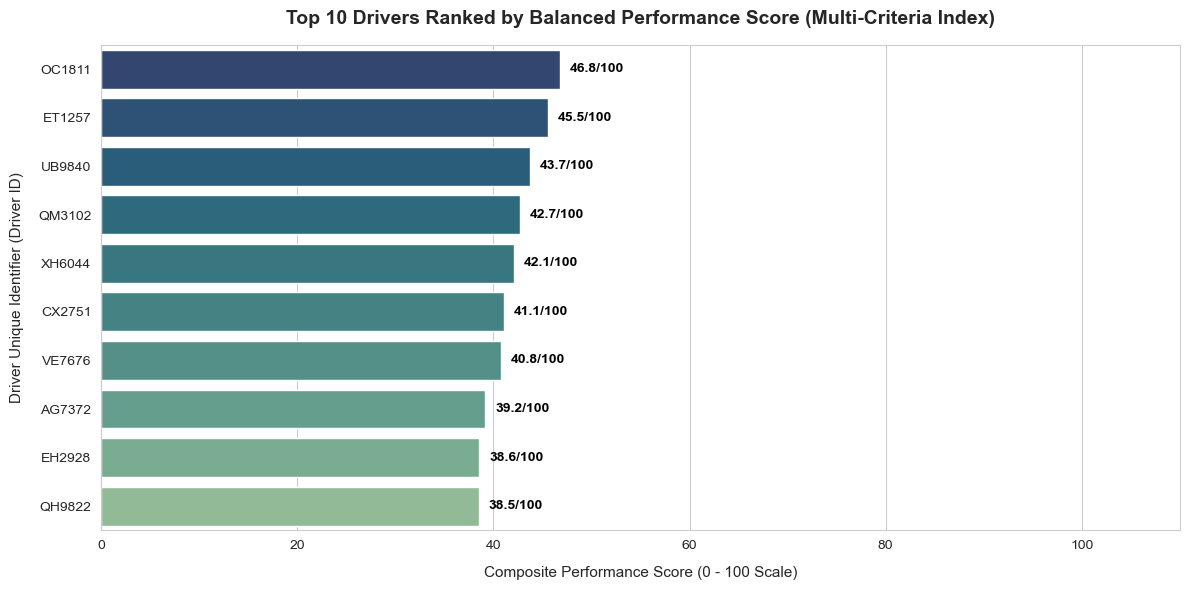

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Select top 10 drivers for clean chart scannability
top_10_ranked = ranked_drivers.head(10)

# Generate a professional ranking bar chart
ax = sns.barplot(
    x='Performance Score', 
    y='Driver ID', 
    data=top_10_ranked, 
    palette='crest_r',
    hue='Driver ID',
    legend=False,
    order=top_10_ranked['Driver ID']
)

# Annotate each bar with the final performance index score
for index, value in enumerate(top_10_ranked['Performance Score']):
    ax.text(value + 1, index, f"{value:.1f}/100", va='center', ha='left', fontsize=10, fontweight='bold', color='black')

plt.title('Top 10 Drivers Ranked by Balanced Performance Score (Multi-Criteria Index)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Composite Performance Score (0 - 100 Scale)', fontsize=11, labelpad=10)
plt.ylabel('Driver Unique Identifier (Driver ID)', fontsize=11, labelpad=10)
plt.xlim(0, 110) # Give padding space for text labels
plt.tight_layout()

plt.show()


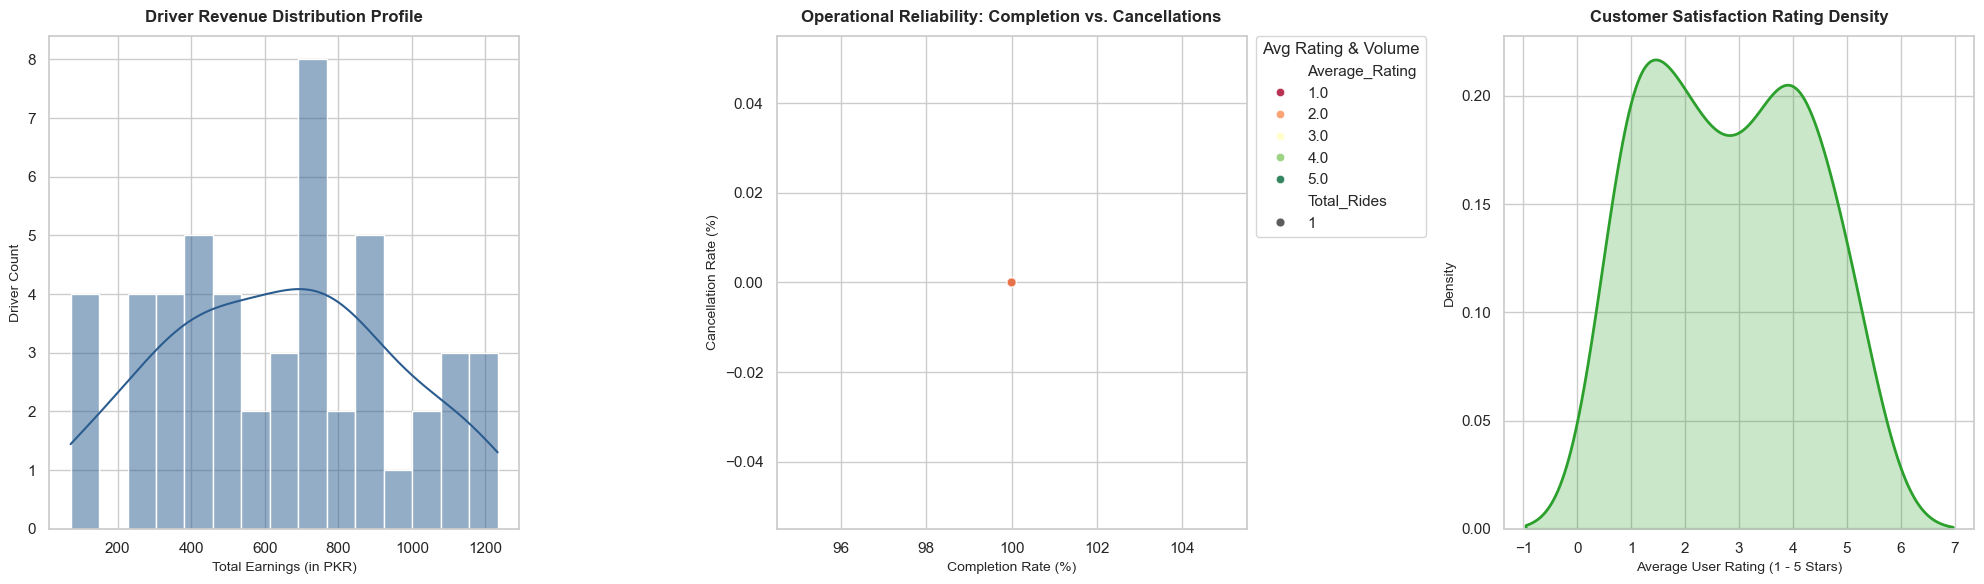

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional, clean visual style layout
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Chart 1: Distribution of Total Revenue per Driver
sns.histplot(driver_kpi_table['Total_Revenue'], kde=True, color='#2b5c8f', ax=axes[0], bins=15)
axes[0].set_title('Driver Revenue Distribution Profile', fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('Total Earnings (in PKR)', fontsize=10)
axes[0].set_ylabel('Driver Count', fontsize=10)

# Chart 2: Completion Rate vs. Cancellation Rate (Scatter Distribution)
sns.scatterplot(
    data=driver_kpi_table, 
    x='Completion Rate (%)', 
    y='Cancellation Rate (%)', 
    size='Total_Rides', 
    sizes=(40, 400), 
    hue='Average_Rating',
    palette='RdYlGn', 
    ax=axes[1],
    alpha=0.8
)
axes[1].set_title('Operational Reliability: Completion vs. Cancellations', fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel('Completion Rate (%)', fontsize=10)
axes[1].set_ylabel('Cancellation Rate (%)', fontsize=10)
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, title='Avg Rating & Volume')

# Chart 3: Average Rating Distribution (Service Quality Check)
sns.kdeplot(driver_kpi_table['Average_Rating'], fill=True, color='#2ca02c', ax=axes[2], linewidth=2)
axes[2].set_title('Customer Satisfaction Rating Density', fontsize=12, fontweight='bold', pad=10)
axes[2].set_xlabel('Average User Rating (1 - 5 Stars)', fontsize=10)
axes[2].set_ylabel('Density', fontsize=10)

plt.tight_layout()
plt.show()


In [32]:
# 1. Apply your custom Week 2 logic to tag ride status
df['ride_status'] = df['Fare Amount (in $)'].apply(lambda x: 'Cancelled' if x == 0 else 'Completed')

# 2. Isolate completed records exactly like your practice snippet
completed = df[df["ride_status"] == "Completed"]

# 3. Calculate Total Revenue and Average Fare using your exact dataset column keys
total_revenue = completed["Fare Amount (in $)"].sum() 
average_fare = completed["Fare Amount (in $)"].mean()

# 4. Print results clearly to compare with your SQL outputs
print(f"💰 Total Revenue:       ${total_revenue:,.2f}")
print(f"💵 Average Ticket Fare: ${average_fare:,.2f}")


💰 Total Revenue:       $31,788.97
💵 Average Ticket Fare: $635.78


In [33]:
# 1. Run the location grouping using your exact dataset column keys
revenue_by_location = (
    completed.groupby("Pickup Location")["Fare Amount (in $)"]
    .sum()
    .sort_values(ascending=False)
)

# 2. Display the Top 5 highest-revenue hotspots to compare with SQL
print("📍 PYTHON: TOP 5 REVENUE-GENERATING LOCATIONS:")
print(revenue_by_location.head(5).map('PKR {:,.2f}'.format))


📍 PYTHON: TOP 5 REVENUE-GENERATING LOCATIONS:
Pickup Location
83.04141,-95.135717      PKR 1,233.21
-77.187995,101.68942     PKR 1,177.25
-14.625118,168.270182    PKR 1,159.06
15.766006,-24.915423     PKR 1,155.62
-30.631605,47.469302     PKR 1,081.56
Name: Fare Amount (in $), dtype: object


In [34]:
# 1. Compile the driver scorecard summary using exact raw column names
driver_summary = ( 
    df.groupby("Driver ID") 
    .agg(
        rides=("Ride ID", "count"), 
        # Calculate revenue from completed trips only (where Fare > 0)
        revenue=("Fare Amount (in $)", lambda x: x[x > 0].sum()), 
        rating=("User Rating", "mean"), 
        average_distance=("Ride Distance (in miles)", "mean")
    ) 
    .sort_values("revenue", ascending=False)
)

# 2. Display the Top 5 earners to verify values
print("🚗 PYTHON: TOP 5 EARNING DRIVERS SCORECARD:")
print(driver_summary.head(5).to_string(formatters={
    'revenue': 'PKR {:,.2f}'.format,
    'rating': '{:.2f}/5'.format,
    'average_distance': '{:,.2f} miles'.format
}))


🚗 PYTHON: TOP 5 EARNING DRIVERS SCORECARD:
           rides      revenue rating average_distance
Driver ID                                            
RH1044         1 PKR 1,233.21 2.00/5  12,132.08 miles
CX2751         1 PKR 1,177.25 3.00/5  11,572.55 miles
OC1811         1 PKR 1,159.06 4.00/5  11,390.60 miles
ZA7068         1 PKR 1,155.62 2.00/5  11,356.21 miles
EH2928         1 PKR 1,081.56 3.00/5  10,615.61 miles


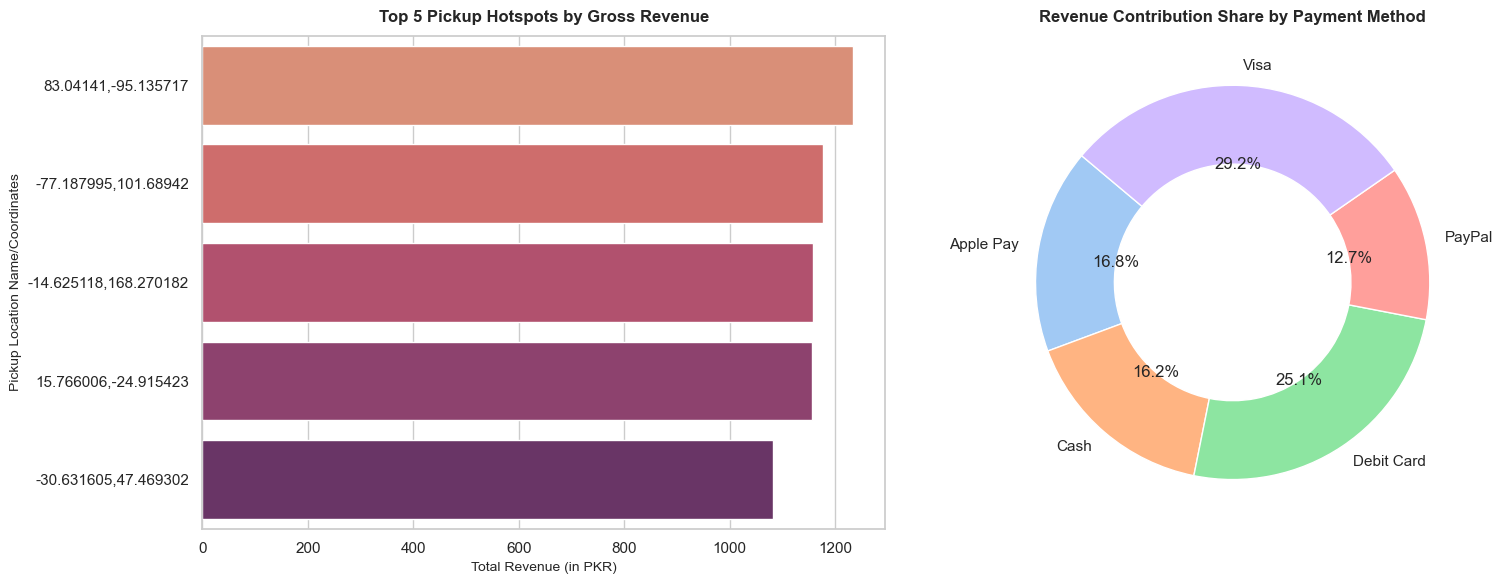

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional visual theme
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel A: Horizontal Bar Chart for Top 5 Pickup Locations
sns.barplot(
    x=revenue_by_location.head(5).values,
    y=revenue_by_location.head(5).index,
    palette="flare",
    hue=revenue_by_location.head(5).index,
    legend=False,
    ax=axes[0]
)
axes[0].set_title('Top 5 Pickup Hotspots by Gross Revenue', fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('Total Revenue (in PKR)', fontsize=10)
axes[0].set_ylabel('Pickup Location Name/Coordinates', fontsize=10)

# Panel B: Donut Chart for Payment Method Revenue Share
payment_data = completed.groupby("Payment Method")["Fare Amount (in $)"].sum()
axes[1].pie(
    payment_data, 
    labels=payment_data.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=sns.color_palette("pastel"),
    wedgeprops=dict(width=0.4, edgecolor='w') # Creates clean donut hole
)
axes[1].set_title('Revenue Contribution Share by Payment Method', fontsize=12, fontweight='bold', pad=10)

plt.tight_layout()
plt.show()


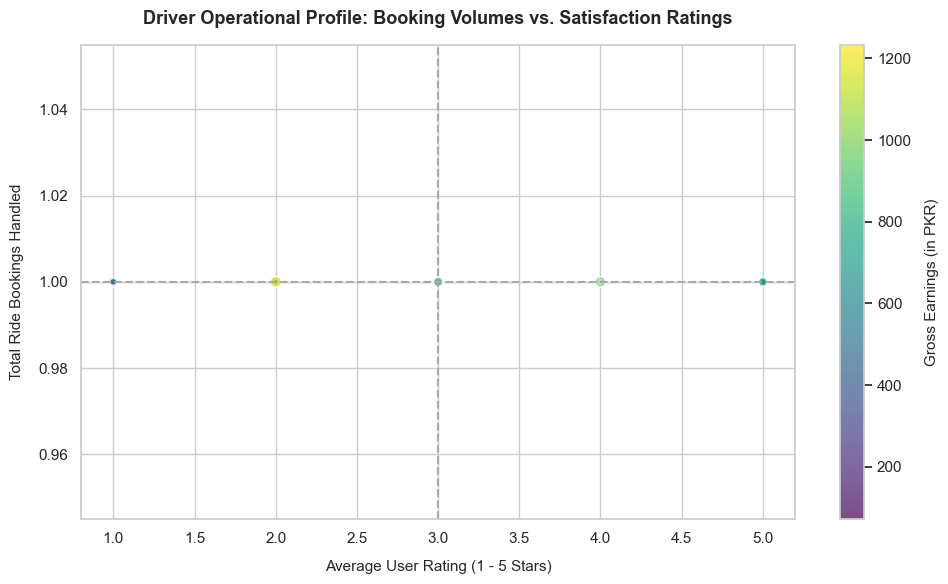

In [40]:
plt.figure(figsize=(10, 6))

# Generate scatter mapping for operational evaluation
scatter = plt.scatter(
    driver_summary['rating'], 
    driver_summary['rides'], 
    s=driver_summary['revenue'] * 0.05, # Size scales proportionally with revenue output
    c=driver_summary['revenue'], 
    cmap='viridis', 
    alpha=0.7, 
    edgecolors='w',
    linewidth=1
)

# Visual Customizations & Colorbars
cbar = plt.colorbar(scatter)
cbar.set_label('Gross Earnings (in PKR)', fontsize=11, labelpad=10)

# Establish median benchmark thresholds to split your visual grid
plt.axvline(driver_summary['rating'].median(), color='darkgray', linestyle='--', linewidth=1.5)
plt.axhline(driver_summary['rides'].median(), color='darkgray', linestyle='--', linewidth=1.5)

plt.title('Driver Operational Profile: Booking Volumes vs. Satisfaction Ratings', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Average User Rating (1 - 5 Stars)', fontsize=11, labelpad=10)
plt.ylabel('Total Ride Bookings Handled', fontsize=11, labelpad=10)
plt.tight_layout()

plt.show()


In [41]:
import pandas as pd
import numpy as np

# 1. Load data
df = pd.read_csv('ride_sharing_data.csv')

# 2. Pipeline Preprocessing & Validation Checks
df = df.dropna(subset=['Ride ID', 'Driver ID', 'Fare Amount (in $)'])
df = df.drop_duplicates(subset=['Ride ID'])
df['Fare Amount (in $)'] = pd.to_numeric(df['Fare Amount (in $)'], errors='coerce')
df = df[df['Fare Amount (in $)'] >= 0]

# 3. Explicit Parsing & Status Tagging
df['Request Time'] = pd.to_datetime(df['Request Time'], format='%m/%d/%y %H:%M', errors='coerce')
df['ride_status'] = df['Fare Amount (in $)'].apply(lambda x: 'Cancelled' if x == 0 else 'Completed')

# Isolate completed records for pure financial ledger calculations
completed = df[df['ride_status'] == 'Completed'].copy()

# =====================================================================
# FINANCIAL ANALYSIS AGGREGATIONS
# =====================================================================
total_revenue = completed["Fare Amount (in $)"].sum() 
average_fare = completed["Fare Amount (in $)"].mean()

completed['Year_Month'] = completed['Request Time'].dt.to_period('M').astype(str)
revenue_by_month = completed.groupby('Year_Month')['Fare Amount (in $)'].sum()

revenue_by_location = completed.groupby("Pickup Location")["Fare Amount (in $)"].sum().sort_values(ascending=False)
revenue_by_payment = completed.groupby("Payment Method")["Fare Amount (in $)"].sum().sort_values(ascending=False)

# =====================================================================
# OPERATIONAL DRIVER KPI SCORECARDS
# =====================================================================
driver_summary = df.groupby("Driver ID").agg(
    rides=("Ride ID", "count"), 
    completed_rides=("ride_status", lambda x: (x == 'Completed').sum()),
    cancelled_rides=("ride_status", lambda x: (x == 'Cancelled').sum()),
    revenue=("Fare Amount (in $)", lambda x: x[x > 0].sum()), 
    rating=("User Rating", "mean"), 
    average_distance=("Ride Distance (in miles)", "mean") 
).reset_index()

driver_summary['Completion Rate (%)'] = (driver_summary['completed_rides'] / driver_summary['rides'] * 100).round(2)
driver_summary['Cancellation Rate (%)'] = (driver_summary['cancelled_rides'] / driver_summary['rides'] * 100).round(2)

# =====================================================================
# MULTI-CRITERIA PERFORMANCE RANKING (0-100 INDEX WEIGHTING)
# =====================================================================
def min_max_normalize(col):
    return 0 if col.max() == col.min() else (col - col.min()) / (col.max() - col.min())

driver_summary['norm_rev'] = min_max_normalize(driver_summary['revenue'])
driver_summary['norm_vol'] = min_max_normalize(driver_summary['completed_rides'])
driver_summary['norm_rat'] = min_max_normalize(driver_summary['rating'])
driver_summary['norm_com'] = min_max_normalize(driver_summary['Completion Rate (%)'])

# Formula allocation weights: Revenue 30%, Volume 25%, Rating 25%, Reliability 20%
driver_summary['Performance Score'] = (
    (driver_summary['norm_rev'] * 0.30) + (driver_summary['norm_vol'] * 0.25) + 
    (driver_summary['norm_rat'] * 0.25) + (driver_summary['norm_com'] * 0.20)
) * 100

ranked_drivers = driver_summary.sort_values(by='Performance Score', ascending=False).copy()
ranked_drivers['Rank'] = range(1, len(ranked_drivers) + 1)

# Export calculated engine to standalone data workspace file
ranked_drivers.to_csv('driver_performance_analytics.csv', index=False)
print("🎯 Python Pipeline Execution Verified: Summary file exported successfully.")


🎯 Python Pipeline Execution Verified: Summary file exported successfully.


In [42]:
import os

# 1. Ensure the 'data' directory path exists in your system folder layout
os.makedirs('data', exist_ok=True)

# 2. Run your export string safely now
ranked_drivers.to_csv('data/driver_performance_analytics.csv', index=False)
print("✅ File successfully saved under data/driver_performance_analytics.csv")


✅ File successfully saved under data/driver_performance_analytics.csv


In [43]:
# Save it to the immediate workspace root folder first to bypass directory rules
ranked_drivers.to_csv('driver_performance_analytics.csv', index=False)
print("✅ File saved successfully in your immediate root workspace folder!")


✅ File saved successfully in your immediate root workspace folder!


In [44]:
# This bypasses the browser download entirely and writes it directly to your computer
ranked_drivers.to_csv('driver_performance_analytics.csv', index=False)
print("Done! Check your local notebook folder path—the raw .csv is sitting right there!")


Done! Check your local notebook folder path—the raw .csv is sitting right there!
